***Assignment***

Complete the following exercises using Python.

**1. Probability and Expected Value**

   - Generate 10,000 random samples of flipping 3 coins (use `np.random.binomial()`)
   - Plot the probability distribution of getting 0, 1, 2, or 3 heads
   - Calculate the expected value (mean) of your distribution

In [18]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
# Set random seed for reproducibility
np.random.seed(42)

In [11]:
# Run 10,000 experiments
# In each experiment, flip 3 coins
# Count how many heads appear in each experiment

coin_flips = np.random.binomial(n=3, p=0.5, size=10000)

coin_flips[:10]   # View first 10 results

array([1, 3, 2, 2, 1, 1, 0, 2, 2, 2])

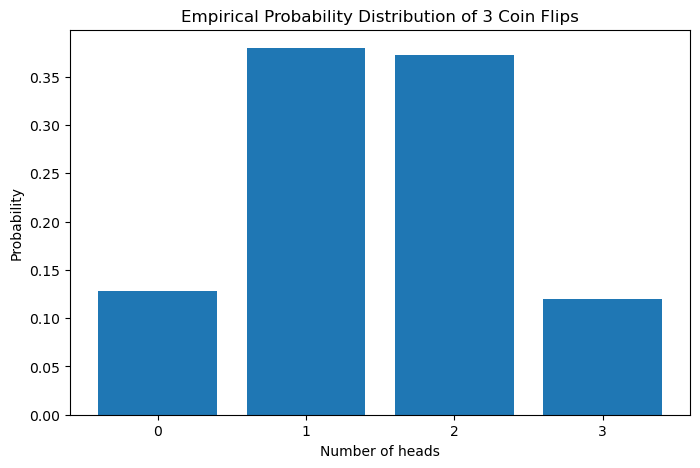

In [12]:
# Plot the probability distribution of getting 0, 1, 2, or 3 heads

# Define possible outcomes
outcomes = np.array([0, 1, 2, 3])

# Count how many times each outcome appears
counts = np.array([(coin_flips == i).sum() for i in outcomes])

# Convert counts into empirical probabilities
empirical_prob = counts / len(coin_flips)

# Plot empirical probability distribution
plt.figure(figsize=(8, 5))
plt.bar(outcomes, empirical_prob)

plt.xlabel("Number of heads")
plt.ylabel("Probability")
plt.title("Empirical Probability Distribution of 3 Coin Flips")
plt.xticks(outcomes)

plt.show()

In [6]:
# Calculate the expected value, mean
expected_value = np.mean(coin_flips)

print("Expected value (mean):", expected_value)

Expected value (mean): 1.4842


In [13]:
# Compare empirical results with theoretical probability

# Calculate theoretical probabilities
theoretical_prob = st.binom.pmf(outcomes, 3, 0.5)

# Print both empirical and theoretical probabilities
for i in range(len(outcomes)):
    print(f"{outcomes[i]} heads: Empirical = {empirical_prob[i]:.4f}, Theoretical = {theoretical_prob[i]:.4f}")

0 heads: Empirical = 0.1278, Theoretical = 0.1250
1 heads: Empirical = 0.3798, Theoretical = 0.3750
2 heads: Empirical = 0.3728, Theoretical = 0.3750
3 heads: Empirical = 0.1196, Theoretical = 0.1250


The graph shows the empirical probability distribution from 10,000 simulated experiments of flipping 3 coins. The expected value gives the mean number of heads from the simulation. The empirical probabilities are close to the theoretical probabilities, showing that the simulation matches the expected distribution.

**2. Normal Distribution and Statistical Testing**

   - Generate two samples from normal distributions:
     - Sample A: 100 values with mean=70, std=5
     - Sample B: 100 values with mean=73, std=5
   - Create a box plot comparing the two distributions
   - Conduct an independent t-test to determine if the means are significantly different
   - Calculate and visualize the 95% confidence intervals for both samples

In [14]:
# Generate Sample A
sample_a = np.random.normal(loc=70, scale=5, size=100)

# Generate Sample B
sample_b = np.random.normal(loc=73, scale=5, size=100)

# View first 5 values from each sample
print("Sample A first 5 values:", sample_a[:5])
print("Sample B first 5 values:", sample_b[:5])

Sample A first 5 values: [62.56069148 64.37406949 71.94409455 64.13063337 75.56317153]
Sample B first 5 values: [72.83487368 70.4817487  72.13812521 76.57365864 79.38928328]


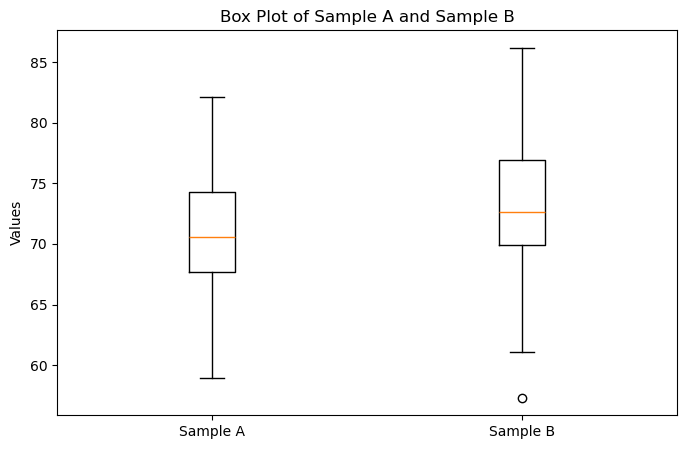

In [15]:
# Plot box plot for both samples
plt.figure(figsize=(8, 5))
plt.boxplot([sample_a, sample_b], labels=["Sample A", "Sample B"])

plt.ylabel("Values")
plt.title("Box Plot of Sample A and Sample B")

plt.show()

In [16]:
# Perform independent t-test
t_stat, p_value = st.ttest_ind(sample_a, sample_b)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.7124352847726922
P-value: 0.007267060676251874


In [17]:
# Function to calculate 95% confidence interval
def confidence_interval(sample):
    mean = np.mean(sample)
    sem = st.sem(sample)
    margin = sem * st.t.ppf(0.975, len(sample) - 1)
    lower = mean - margin
    upper = mean + margin
    return mean, lower, upper

# Calculate confidence interval for Sample A
mean_a, lower_a, upper_a = confidence_interval(sample_a)

# Calculate confidence interval for Sample B
mean_b, lower_b, upper_b = confidence_interval(sample_b)

print("Sample A mean:", mean_a)
print("Sample A 95% CI:", (lower_a, upper_a))

print("Sample B mean:", mean_b)
print("Sample B 95% CI:", (lower_b, upper_b))

Sample A mean: 70.89076617989603
Sample A 95% CI: (69.89281941404673, 71.88871294574534)
Sample B mean: 72.85135192222528
Sample B 95% CI: (71.82126080629739, 73.88144303815317)


Sample A and Sample B were generated from normal distributions with different means. The box plot helps compare the spread and centre of the two samples. The independent t-test checks whether the difference in means is statistically significant. If the p-value is less than 0.05, the means are significantly different. The 95% confidence intervals show the range in which the true mean is likely to fall for each sample.

**3. Correlation Analysis**
   - Using the iris dataset (from seaborn), analyze the relationship between:
     - Sepal length and petal length
     - Sepal width and petal width
   - For each pair:
     - Create a scatter plot
     - Calculate the Pearson correlation coefficient and p-value
     - Calculate and interpret the R-squared value
   - Which pair shows a stronger relationship? Explain why.

In [19]:
# Load the iris dataset
iris = sns.load_dataset("iris")

# Select variables
x1 = iris["sepal_length"]
y1 = iris["petal_length"]

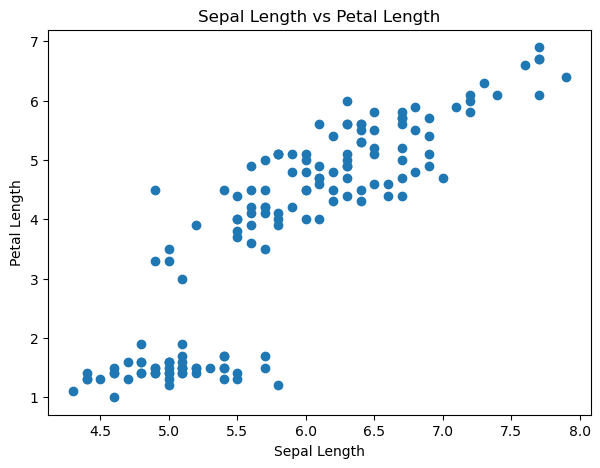

In [20]:
# Scatter plot for sepal length and petal length
plt.figure(figsize=(7, 5))
plt.scatter(x1, y1)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Sepal Length vs Petal Length")

plt.show()

In [21]:
# Calculate Pearson correlation coefficient and p-value
r1, p1 = st.pearsonr(x1, y1)

print("Pearson correlation coefficient:", r1)
print("P-value:", p1)

Pearson correlation coefficient: 0.8717537758865831
P-value: 1.0386674194498827e-47


In [22]:
# Calculate R-squared
r_squared_1 = r1 ** 2

print("R-squared:", r_squared_1)
print("Interpretation: This shows how much of the variation in petal length is explained by sepal length.")

R-squared: 0.7599546457725149
Interpretation: This shows how much of the variation in petal length is explained by sepal length.


In [23]:
# Select variables
x2 = iris["sepal_width"]
y2 = iris["petal_width"]

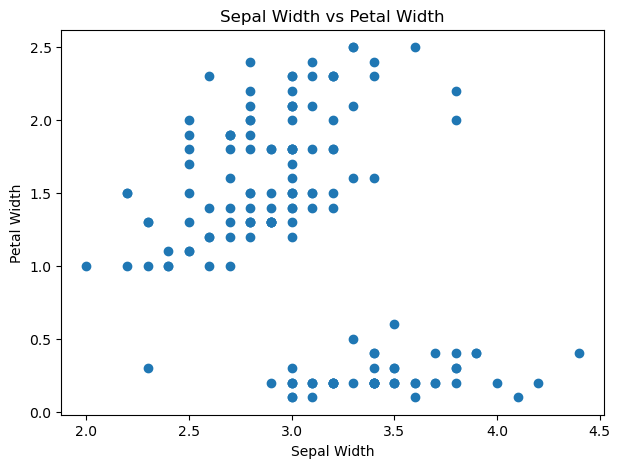

In [24]:
# Scatter plot for sepal width and petal width
plt.figure(figsize=(7, 5))
plt.scatter(x2, y2)

plt.xlabel("Sepal Width")
plt.ylabel("Petal Width")
plt.title("Sepal Width vs Petal Width")

plt.show()

In [25]:
# Calculate Pearson correlation coefficient and p-value
r2, p2 = st.pearsonr(x2, y2)

print("Pearson correlation coefficient:", r2)
print("P-value:", p2)

Pearson correlation coefficient: -0.36612593253643905
P-value: 4.0732285132462e-06


In [26]:
# Calculate R-squared
r_squared_2 = r2 ** 2

print("R-squared:", r_squared_2)
print("Interpretation: This shows how much of the variation in petal width is explained by sepal width.")

R-squared: 0.13404819847567712
Interpretation: This shows how much of the variation in petal width is explained by sepal width.


In [27]:
# Compare both pairs
print("Sepal Length vs Petal Length")
print("Correlation coefficient:", r1)
print("R-squared:", r_squared_1)

print("\nSepal Width vs Petal Width")
print("Correlation coefficient:", r2)
print("R-squared:", r_squared_2)

# Identify stronger relationship
if abs(r1) > abs(r2):
    print("\nSepal length and petal length show the stronger relationship.")
    print("This is because the absolute value of the correlation coefficient is higher,")
    print("and the R-squared value is also larger.")
else:
    print("\nSepal width and petal width show the stronger relationship.")
    print("This is because the absolute value of the correlation coefficient is higher,")
    print("and the R-squared value is also larger.")

Sepal Length vs Petal Length
Correlation coefficient: 0.8717537758865831
R-squared: 0.7599546457725149

Sepal Width vs Petal Width
Correlation coefficient: -0.36612593253643905
R-squared: 0.13404819847567712

Sepal length and petal length show the stronger relationship.
This is because the absolute value of the correlation coefficient is higher,
and the R-squared value is also larger.


The scatter plots show the relationship between each pair of variables. The Pearson correlation coefficient measures the strength and direction of the linear relationship. The p-value shows whether the relationship is statistically significant. The R-squared value shows how much variation in one variable is explained by the other. The pair with the larger absolute correlation coefficient and larger R-squared value has the stronger relationship.